## **XGBoost**

In [ ]:
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

import xgboost as xgb
import optuna
from tqdm import tqdm
from scipy.stats import uniform, randint, loguniform

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix, 
    roc_curve, 
    auc
)

### Data Loading and Preparation

In [ ]:
# Load the datasets
df_train = pd.read_csv('../train_coded.csv')
df_test = pd.read_csv('../test_coded.csv')

# Split features and labels
X_train = df_train.drop(columns=["label"])
y_train = df_train["label"]

X_test = df_test.drop(columns=["label"])
y_test = df_test["label"]

print("Dataset shapes:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")

Dataset shapes:
X_train: (31980, 805)
y_train: (31980,)
X_test:  (7996, 805)
y_test:  (7996,)


### Hyperparameter Tuning with Optuna & XGBoost 

In [3]:
# Define Optuna Objective
def objective(trial):
    print(f"\nStarting trial {trial.number}", end="")
    # Define search space (Hyperparameters)
    params = {
        # Fixed Parameters (GPU and Multiclass)
        'objective': 'multi:softprob',
        'num_class': len(y_train.unique()),
        'device': 'cuda',               # Activate GPU
        'tree_method': 'hist',          # Optimized histogram algorithm
        'eval_metric': 'mlogloss',      
        'verbosity': 0,
        
        # Parameters to Optimize
        'n_estimators': trial.suggest_int('n_estimators', 250, 1700),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.9),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 100.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
    }
    
    # Model setup with current trial parameters
    model = xgb.XGBClassifier(**params)
    
    # 5-Split Stratified Cross-Validation
    # n_jobs=1 because the GPU already handles internal parallelism
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculate average score (f1_macro) across 5 folds
    # Note: Early stopping is not used here for methodological purity
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=1)
    
    # manual cleaning
    del model
    gc.collect()
    
    return scores.mean()

# Execute Study
print("Starting robust GPU Optuna Search...")
optuna.logging.set_verbosity(optuna.logging.WARNING) # Reduce log clutter, show results only

study = optuna.create_study(direction='maximize')
n_trials = 100 # 100 trials is a solid standard

# Create a tqdm progress bar
with tqdm(total=n_trials, desc="Optimizing", unit="trial") as pbar:
    # Callback to update tqdm bar
    def tqdm_callback(study, trial):
        pbar.update(1)
        # Update description with best score so far
        try:
            best_score = study.best_value
            pbar.set_description(f"Best F1: {best_score:.4f}")
        except ValueError:
            pass # No best value yet

    # Run the optimization with the callback
    study.optimize(objective, n_trials=n_trials, callbacks=[tqdm_callback])

# Results and Best Model Creation 
print(f"Best CV Score: {study.best_value:.4f}")
print("Best Parameters:")
print(study.best_params)

# Retrieve best parameters
best_params = study.best_params

# Add fixed parameters that Optuna didn't optimize
best_params['objective'] = 'multi:softprob'
best_params['num_class'] = len(y_train.unique())
best_params['device'] = 'cuda'
best_params['tree_method'] = 'hist'
best_params['eval_metric'] = 'mlogloss'
best_params['verbosity'] = 0

# Create final model
best_model = xgb.XGBClassifier(**best_params)

# Train on the FULL training set (without external early stopping)
# Using the optimized number of estimators found via CV
print("Refitting best model on full training set...")
best_model.fit(X_train, y_train)
print("Done.")

Starting robust GPU Optuna Search...


Optimizing:   0%|          | 0/100 [00:00<?, ?trial/s]


Starting trial 0

Best F1: 0.6138:   1%|          | 1/100 [03:20<5:30:07, 200.08s/trial]


Starting trial 1

...


Starting trial 98

Best F1: 0.6469:  99%|█████████▉| 99/100 [11:44:36<06:33, 393.27s/trial]


Starting trial 99

Best F1: 0.6469: 100%|██████████| 100/100 [11:51:32<00:00, 426.92s/trial]


Best CV Score: 0.6469
Best Parameters:
{'n_estimators': 1569, 'learning_rate': 0.08283667595505992, 'max_depth': 4, 'colsample_bytree': 0.8994465816304935, 'subsample': 0.6067371400047036, 'gamma': 0.9725120855772141, 'reg_alpha': 0.001574449949637585, 'reg_lambda': 64.79614009806988, 'min_child_weight': 6}
Refitting best model on full training set...
Done.


### Model Training and Classification Report

In [ ]:
# 1. Predict on the Test Set
print("Making predictions on the test set...")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)  # Required for ROC Curve

# 2. Basic Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Making predictions on the test set...
Test Set Accuracy: 0.6560

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.61      0.61      1600
           1       0.63      0.61      0.62      1600
           2       0.63      0.69      0.66      1600
           3       0.71      0.69      0.70      1600
           4       0.69      0.69      0.69      1596

    accuracy                           0.66      7996
   macro avg       0.66      0.66      0.66      7996
weighted avg       0.66      0.66      0.66      7996



### Defining Class Names for Evaluation and Plotting

In [5]:
# Define the mapping from integer class to string label
class_labels = {
    0: 'BPD',
    1: 'bipolar',
    2: 'depression',
    3: 'anxiety',
    4: 'schizophrenia'
}

# Create a list of names in the correct order for plotting
class_names = [class_labels[i] for i in range(len(class_labels))]
print(f"Class Names: {class_names}")

Class Names: ['BPD', 'bipolar', 'depression', 'anxiety', 'schizophrenia']


### Confusion Matrix

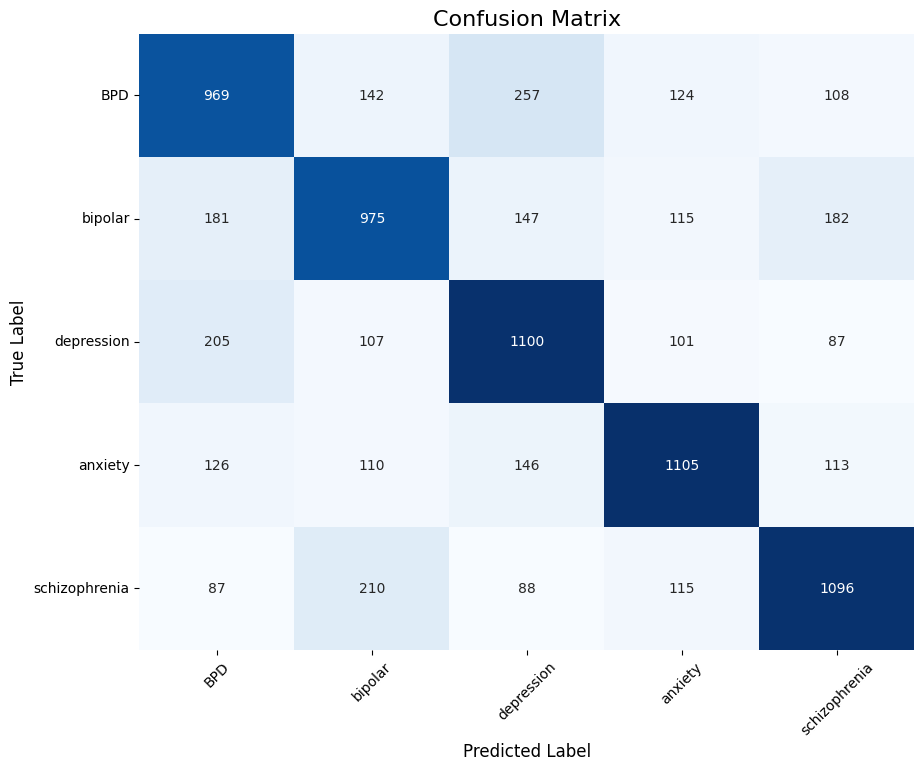

In [ ]:
# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45) # Rotate x-labels for better readability
plt.yticks(rotation=0)
plt.show()

### ROC curve

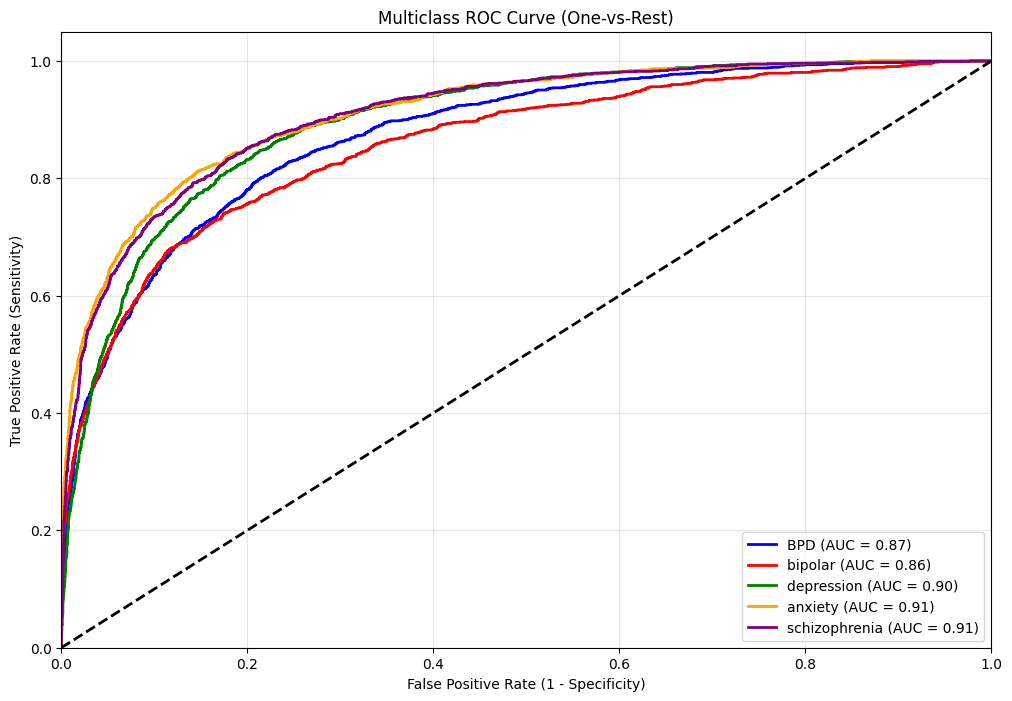

In [ ]:
# 1. Binarize the output labels for One-vs-Rest ROC
classes = best_model.classes_ # Expected to be [0, 1, 2, 3, 4]
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# 2. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Calculate ROC for the ith class vs all other classes
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plotting all ROC curves
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(n_classes), colors):
    # Use class_names[i] to get the string label ('BPD', etc.)
    label_text = f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=label_text)

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Performance metrics per class

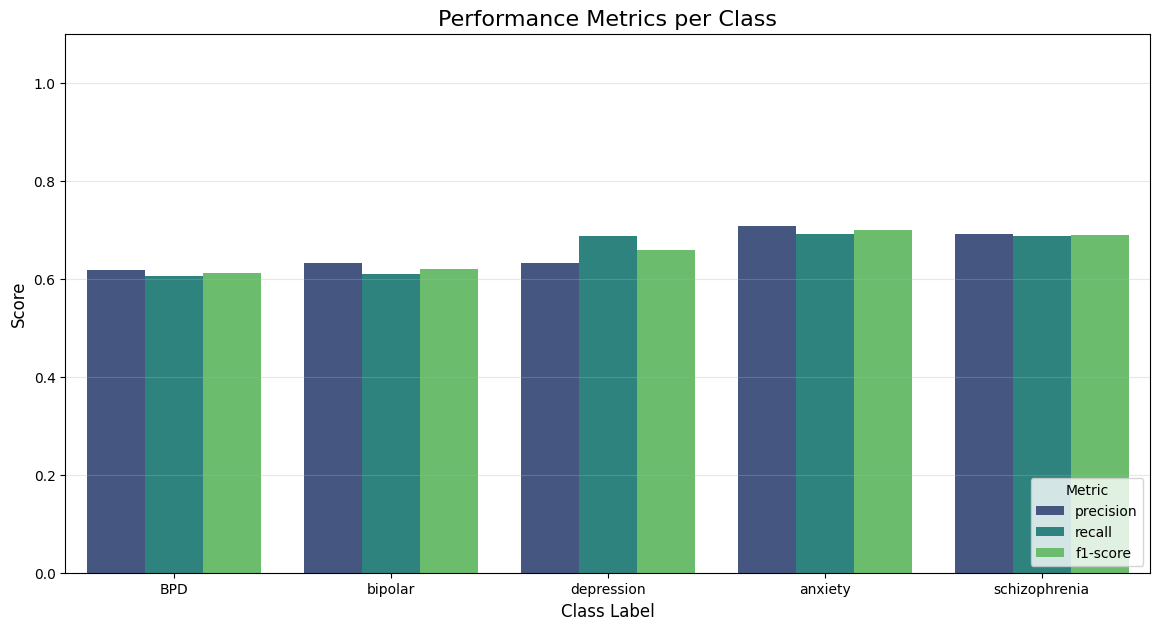

In [ ]:
# 1. Generate report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# 2. Convert to DataFrame and clean up
df_metrics = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' to focus on classes only
df_metrics_classes = df_metrics.drop(['accuracy', 'macro avg', 'weighted avg']).copy()

# Replace the numeric index with class names
# We ensure the index is integer to map correctly, then map to strings
df_metrics_classes.index = df_metrics_classes.index.astype(int).map(class_labels)

# 3. Reshape data for Seaborn (Melting)
df_melted = df_metrics_classes[['precision', 'recall', 'f1-score']].reset_index()
df_melted = df_melted.melt(id_vars='index', var_name='Metric', value_name='Score')

# 4. Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='index', y='Score', hue='Metric', palette='viridis')

plt.title('Performance Metrics per Class', fontsize=16)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1.1)  # Set limit slightly above 1 for clarity
plt.legend(title='Metric', loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Saving the model

In [ ]:
# Save the full Sklearn wrapper using Joblib
# Can load it later with: loaded_model = joblib.load("xgboost.pkl")
joblib.dump(best_model, "xgboost.pkl")
print("Full sklearn model wrapper saved to 'xgboost.pkl'")

Full sklearn model wrapper saved to 'xgboost.pkl'
